### Problem Statement/Business Understanding

**Analyze the distribution of prices for Air Conditioners on Flipkart and identify factors that impact price variations**

### Business Questions

- **Which brand offers the highest number of AC models?**
- **Which brand sells the most premium-priced ACs?**
- **Does a higher star rating mean a higher price?**
- **Does tonnage affect the price?**

### Objective

**Objective: Use EDA techniques (like histograms, box plots, and scatter plots) to understand how prices vary across different brands, room sizes, star ratings, and warranty types. This could help reveal pricing trends or outliers in the dataset.**

In [391]:
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import time
import re
from bs4 import BeautifulSoup

### Extracting The Data

In [393]:
scraped_title = []
scraped_prices = []
scraped_ratings = []
scraped_specs = []

for page_num in range(1,21):
    url = f'https://www.flipkart.com/search?q=acs&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={page_num}'
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}    

    response = requests.get(url,headers=headers)

    if response.status_code != 200:
        continue

    soup = BeautifulSoup(response.text,'html.parser')
    product_cards = soup.find_all('div',class_ = 'ZFwe0M row')

    for card in product_cards:
        title_tag = card.find('div',class_ = 'RG5Slk')
        prices_tag = card.find('div',class_ = 'hZ3P6w DeU9vF')
        ratings_tag = card.find('div',class_ = 'MKiFS6')
        specs_tag = card.find('div',class_ = 'CMXw7N')

        scraped_title.append(title_tag.text if title_tag else np.nan)
        scraped_prices.append(prices_tag.text if prices_tag else np.nan)
        scraped_ratings.append(ratings_tag.text if ratings_tag else np.nan)
        scraped_specs.append(specs_tag.text if specs_tag else np.nan)

    time.sleep(1.5)

### Creating the Data Frame

In [395]:
data = {
    'Title' : scraped_title,
    'Price' : scraped_prices,
    'Rating' : scraped_ratings,
    'Specs' : scraped_specs}

df = pd.DataFrame(data)
df

,Title,Price,Rating,Specs
0,Godrej 2026 Model 2 Ton 3 Star Split Inverter ...,"₹36,490",3.9,Annual Power Usage: 1076.57 kWhRoom Size: 180 ...
1,Godrej 2026 Model 1.5 Ton 4 Star Split Inverte...,"₹33,990",4,Annual Power Usage: 728.31 kWhRoom Size: 130 t...
2,Hitachi 2026 Model 1 Ton 3 Star Split Inverter AC,"₹25,490",3.9,Annual Power Usage: 632.61 kWhRoom Size: 80 to...
3,Voltas 2025 Model 0.6 Ton 2 Star Split Fixed S...,"₹19,990",3.8,Annual Power Usage: 475.3 UnitsRoom Size: Up t...
4,Oakter 2026 Model 0.5 Ton 3 Star Window Invert...,"₹16,665",3.8,Annual Power Usage: 307 kWhRoom Size: Up to 80...
...,...,...,...,...
475,Haier 2025 Model 1.5 Ton 3 Star Split Inverter AC,"₹35,991",4,Annual Power Usage: 953.49 kWhRoom Size: 130 t...
476,MOTOROLA 2026 Model 1 Ton 3 Star Split Inverte...,"₹28,990",4.2,Annual Power Usage: 611.13 kWhRoom Size: 80 to...
477,Godrej 2026 Model 1 Ton 3 Star Split Inverter ...,"₹27,549",4,Annual Power Usage: 607.6 kWhRoom Size: 80 to ...
478,Panasonic 2025 Model 1.5 Ton 3 Star Split Inve...,"₹36,660",4.1,Annual Power Usage: 877.07 kWhRoom Size: 130 t...


### Export into .CSV format

In [397]:
df.to_csv('Raw Air Conditioners File.csv',index=False)

In [425]:
print(f'The number of Observations(Rows){df.shape[0]}')
print()
print(f'The number of Features(Columns){df.shape[1]}')
print()
print('DataFrame information')
df.info()
print()
print('The Data Types of Each Feature:')
print(df.dtypes)
print()
print("Missing Values Count per Feature")
print(df.isnull().sum())
print()
print("The count of duplicate values",df.duplicated().sum())

The number of Observations(Rows)480

The number of Features(Columns)4

DataFrame information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   480 non-null    object
 1   Price   479 non-null    object
 2   Rating  455 non-null    object
 3   Specs   480 non-null    object
dtypes: object(4)
memory usage: 15.1+ KB

The Data Types of Each Feature:
Title     object
Price     object
Rating    object
Specs     object
dtype: object

Missing Values Count per Feature
Title      0
Price      1
Rating    25
Specs      0
dtype: int64

The count of duplicate values 219


In [432]:
duplicates = df[df.duplicated(keep=False)]
duplicates.head(20)

,Title,Price,Rating,Specs
0,Godrej 2026 Model 2 Ton 3 Star Split Inverter ...,"₹36,490",3.9,Annual Power Usage: 1076.57 kWhRoom Size: 180 ...
1,Godrej 2026 Model 1.5 Ton 4 Star Split Inverte...,"₹33,990",4,Annual Power Usage: 728.31 kWhRoom Size: 130 t...
3,Voltas 2025 Model 0.6 Ton 2 Star Split Fixed S...,"₹19,990",3.8,Annual Power Usage: 475.3 UnitsRoom Size: Up t...
6,Hisense 2026 Model 2 Ton 3 Star Split Inverter AC,"₹32,990",3.6,Annual Power Usage: 1073.79 kWhRoom Size: 180 ...
7,Godrej 2026 Model 1 Ton 5 Star Split Inverter ...,"₹33,990",4,Annual Power Usage: 468.65 kWhRoom Size: 80 to...
8,Godrej 2026 Model 1.5 Ton 4 Star Split Inverte...,"₹33,990",4,Annual Power Usage: 728.31 kWhRoom Size: 130 t...
10,MOTOROLA 2026 Model 1.5 Ton 3 Star Split Inver...,"₹31,990",4.2,Annual Power Usage: 858.22 kWhRoom Size: 130 t...
11,LG 2026 Model 1.42 Ton 5 Star Split Smart Inve...,"₹47,490",NaN,Annual Power Usage: 1180 WRoom Size: 130 to 18...
12,Daikin 2026 Model 0.9 Ton 2 Star Split Fixed S...,"₹26,990",4.2,Annual Power Usage: 582.13 kWhRoom Size: 80 to...
13,MOTOROLA 2026 Model 2 Ton 3 Star Split Inverte...,"₹38,990",4.2,Annual Power Usage: 1098.15 kWhRoom Size: 180 ...


### Cleaning The Data

In [456]:
print('Rows before removing Duplicates :', len(df))
print('The Count of Duplicate Rows : ',df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Rows after removing Duplicates : ", len(df))

Rows before removing Duplicates : 480
The Count of Duplicate Rows :  219
Rows after removing Duplicates :  261


In [458]:
df['Title'] = df['Title'].astype(str)

In [460]:
df['Specs'] = df['Specs'].astype(str)

In [ ]:
df['Brand'] = df['Title'].str.extract(r'^(.*?)(?=\s+\b20\d{2}\b)')[0].fillna(df['Title'].str.split().str[0])

def clean_brand_name(brand):
    if pd.isna(brand):
        return brand

    brand_lower = str(brand).lower().strip()

    if 'haier' in brand_lower:
        return 'Haier'
    elif 'blue' in brand_lower:
        return 'Blue Star'
    elif 'mitsubishi' in brand_lower:
        return 'MITSUBISHI'
    elif 'lloyd' in brand_lower:
        return 'Lloyd'
    elif 'samsung' in brand_lower:
        return 'Samsung'
    elif 'lg' in brand_lower:
        return 'LG'
    elif 'tcl' in brand_lower:
        return 'TCL'
    elif 'ifb' in brand_lower:
        return 'IFB'

    return str(brand).title().strip()

df['Brand'] = df['Brand'].apply(clean_brand_name)

df['Year'] = df['Title'].str.extract(r'(\b20\d{2}\b)')[0]

df['Ton'] = df['Title'].str.extract(r'(\d+(?:\.\d+)?)\s*(?:tons?|Ton)', flags = re.IGNORECASE)[0]
df['Ton'] = pd.to_numeric(df['Ton'],errors = 'coerce')

df['Star'] = df['Title'].str.extract(r'(\d)\s*(?:star)s?\b',flags = re.IGNORECASE)[0]
df['Star'] = pd.to_numeric(df['Star'],errors = 'coerce')


df['Price'] = df['Price'].astype(str).str.replace(r'[^\d]','',regex=True).replace('',None)
df['Price'] = pd.to_numeric(df['Price'],errors = 'coerce')
df['Price'] = (df['Price'].fillna(df['Price'].median()).astype(int))

df['Rating'] = pd.to_numeric(df['Rating'],errors = 'coerce')
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

df['APU in KWh'] = pd.to_numeric(df['Specs'].str.extract(r'Annual\s+Power\s+Usage:\s*(\d+(?:\.\d+)?)',flags = re.IGNORECASE)[0],errors ='coerce',)

df['Comprehensive warranty in years'] = pd.to_numeric(df['Specs'].str.extract(r'(\d+)\s*(?:-?\s*Year)?\s*(?:Comprehensive\s*)?warranty',flags = re.IGNORECASE)[0],errors = 'coerce').fillna(0).astype(int)
df['Warranty on PCB in years'] = pd.to_numeric(df['Specs'].str.extract(r'(\d+)\s*Year\s+warranty\s+on\s+PCB',flags = re.IGNORECASE)[0],errors = 'coerce').fillna(0).astype(int)
df['Warranty on Compressor in years'] = pd.to_numeric(df['Specs'].str.extract(r'(\d+)\s*(?:-?\s*Year)?\s*(?:warranty\s*on\s*Compressor|Compressor\s*warranty)',flags = re.IGNORECASE)[0],errors = 'coerce').fillna(0).astype(int)

In [ ]:
#Dropping the unnecessary columns

df.drop(columns=['Title','Specs'],inplace=True)

In [477]:
#Sorting the order of the columns

df = df[['Brand','Year','Price','Rating','Star','Ton','APU in KWh','Comprehensive warranty in years','Warranty on in PCB years','Warranty on Compressor in years']]

In [512]:
df.head(10)

,Brand,Year,Price,Rating,Star,Ton,APU in KWh,Comprehensive warranty in years,Warranty on in PCB years,Warranty on Compressor in years
0,Godrej,2026,36490,3.9,3,2.0,1076.57,10,0,10
1,Godrej,2026,33990,4.0,4,1.5,728.31,10,0,10
2,Hitachi,2026,25490,3.9,3,1.0,632.61,1,5,10
3,Voltas,2025,19990,3.8,2,0.6,475.30,0,0,0
4,Oakter,2026,16665,3.8,3,0.5,307.00,0,0,0
5,Haier,2025,28490,4.1,4,1.5,913.00,1,0,0
6,Hisense,2026,32990,3.6,3,2.0,1073.79,1,0,0
7,Godrej,2026,33990,4.0,5,1.0,468.65,10,0,10
8,Hisense,2026,26990,3.9,3,1.5,782.29,1,0,0
9,Motorola,2026,31990,4.2,3,1.5,858.22,0,0,0


In [479]:
df[['Price','Rating','APU in KWh']].describe()

,Price,Rating,APU in KWh
count,261.000000,261.000000,249.000000
mean,38802.670498,4.059387,883.075582
std,10051.462421,0.143708,263.490072
min,16665.000000,3.500000,307.000000
25%,32490.000000,4.000000,701.680000
50%,36494.000000,4.100000,858.220000
75%,43420.000000,4.200000,1050.470000
max,84990.000000,4.400000,2608.740000


In [545]:
from scipy.stats import skew

print('--- Price Statistical Metrics---')
print(f'The Mean Price : {df['Price'].mean():.2f}')
print(f'The Median Price : {df['Price'].median():.2f}')
print(f'The Standard Deviation : {df['Price'].std():.2f}')
print(f'The Skewness :{df['Price'].skew():.2f}')

--- Price Statistical Metrics---
The Mean Price : 38802.67
The Median Price : 36494.00
The Standard Deviation : 10051.46
The Skewness :1.54


**The average price of an AC is ₹38802, but the minimum is lower at ₹16,665, which reveals a right-skewed distribution driven by high-end premium models reaching up to ₹84,990.**

### How are AC Prices Distributed in Flipkart

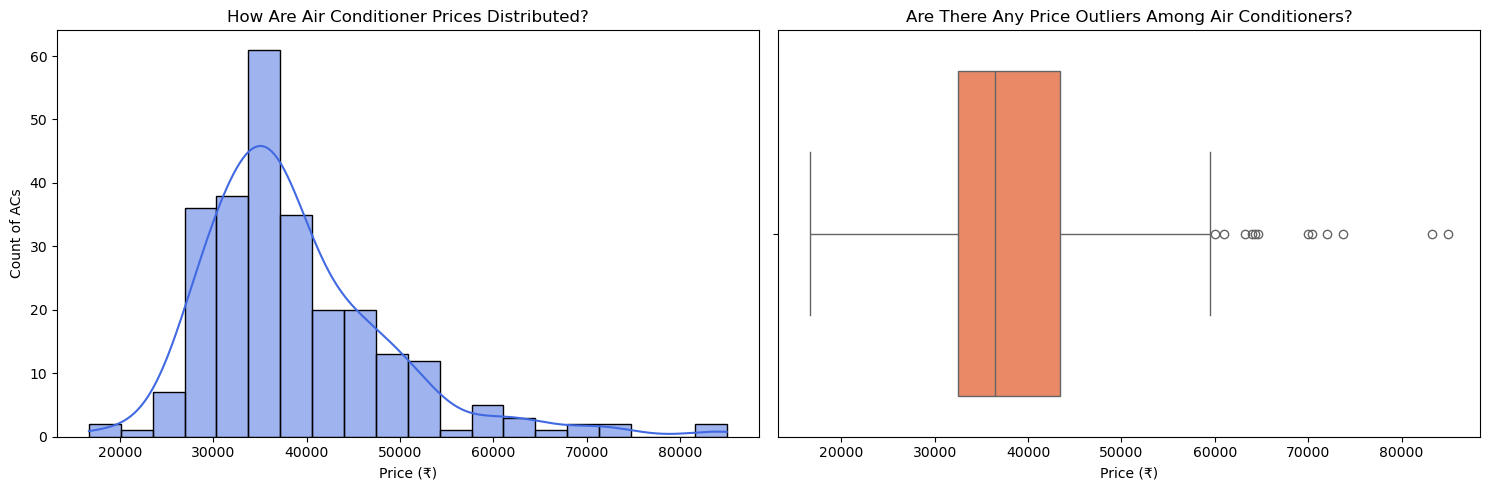

In [484]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2,figsize=(15,5))

sns.histplot(ax=axes[0],data=df,x='Price',kde=True,color ='royalblue')
axes[0].set_title('How Are Air Conditioner Prices Distributed?')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Count of ACs')

sns.boxplot(ax=axes[1],data=df,x="Price",color='coral')
axes[1].set_title('Are There Any Price Outliers Among Air Conditioners?')
axes[1].set_xlabel('Price (₹)')

plt.tight_layout()
plt.show()

### My Interpretations on Price Distribution :
* The histogram shows that air conditioner prices are positively (right) skewed, with most products concentrated between ₹30,000 and ₹40,000. As prices increase beyond this range, the number of available models gradually declines, while a small number of premium-priced air conditioners extend the distribution up to approximately ₹85,000. This indicates that the market is largely dominated by budget and mid-range products, with relatively fewer premium offerings.
  
* The box plot confirms the presence of several high-priced outliers, particularly above ₹60,000, with a few models reaching nearly ₹90,000. The majority of air conditioners are concentrated within a much narrower price range, indicating that premium-priced products represent only a small portion of the overall market. These outliers are likely associated with premium brands or models offering advanced specifications and features.

### Which brand offers the wide range of air conditioner models?

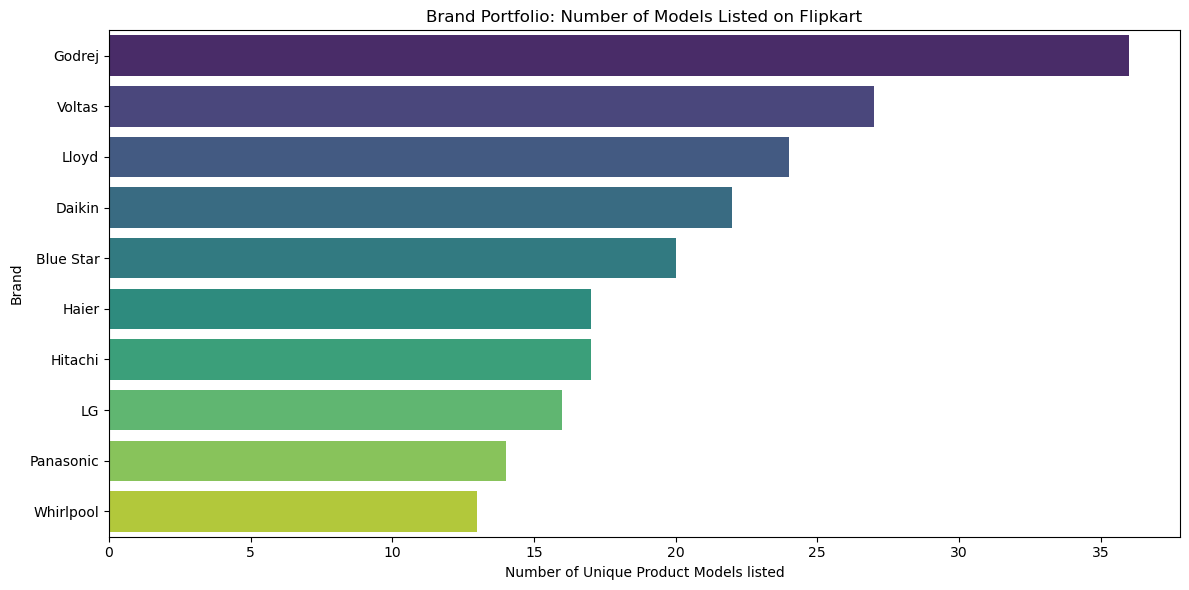

In [486]:
plt.figure(figsize=(12,6))

top_brands = df['Brand'].value_counts().head(10)

sns.barplot(x=top_brands.values,y=top_brands.index,hue=top_brands.index,palette = 'viridis')

plt.title("Brand Portfolio: Number of Models Listed on Flipkart")
plt.xlabel("Number of Unique Product Models listed")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

### My Interpretations on Brand Variety :
* The analysis shows that Godrej offers the largest number of unique air conditioner models listed on Flipkart, followed by Voltas and Lloyd. In contrast, brands such as Panasonic and Whirlpool have comparatively smaller product portfolios. This suggests that some manufacturers provide customers with a broader selection of models, while others focus on a more limited range of products.

  **Note:** This chart reflects the number of listed models, not market share or sales performance.

### Which Brand Commands Premium Pricing?

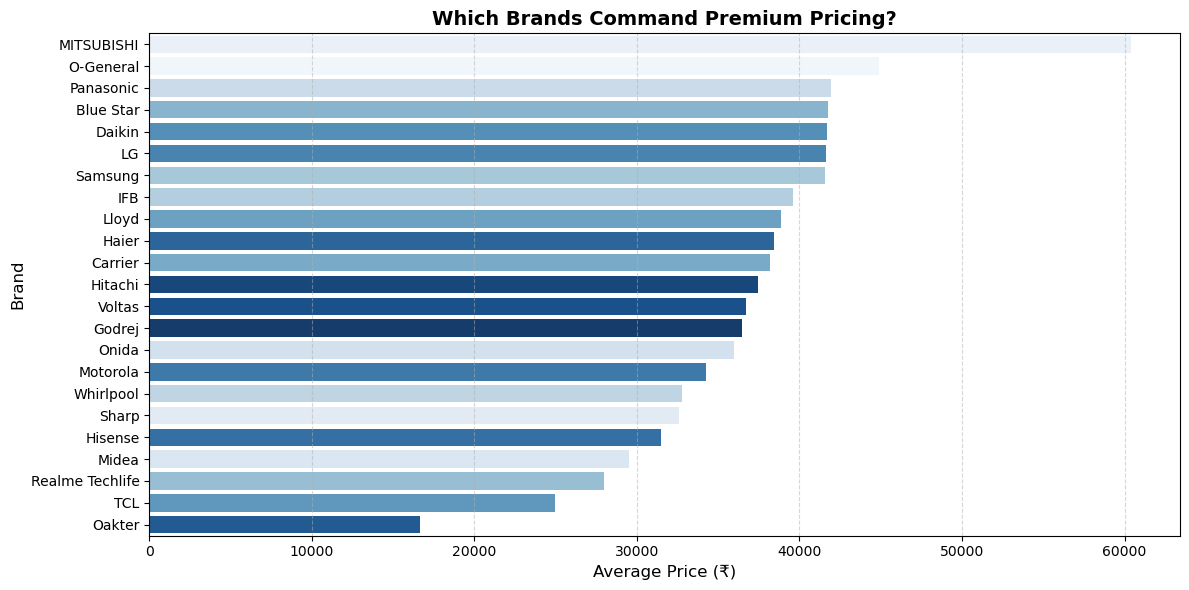

In [488]:
plt.figure(figsize=(12,6))

brand_order = df.groupby("Brand")['Price'].mean().sort_values(ascending=False).index

sns.barplot(x='Price',y='Brand',hue='Brand',legend=False,data=df,order=brand_order,palette='Blues_r',errorbar=None)

plt.title('Which Brands Command Premium Pricing?',fontsize=14,fontweight='bold')
plt.xlabel('Average Price (₹)',fontsize=12)
plt.ylabel('Brand',fontsize=12)
plt.grid(axis='x',linestyle='--',alpha=0.5)

plt.tight_layout()
plt.show()

### My interpretation on Brands with Premimum Pricing:

* The average price comparison indicates that Mitsubishi has the highest average-priced air conditioners among all brands in the dataset, followed by O-Genera, Panasonic and Blue Star. On the other hand, brands such as Realme Techlife, Kenstar, and TCL have comparatively lower average prices. These pricing differences suggest varying brand positioning, with some manufacturers focusing on premium offerings while others primarily compete in the budget and mid-range segments.

In [526]:
df.rename(columns={
    'Comprehensive warranty in years': 'Comprehensive Warranty (Years)',
    'Warranty on Compressor in years': 'Compressor Warranty (Years)',
    'Warranty on in PCB years': 'PCB Warranty (Years)'
}, inplace=True)

In [528]:
df.columns

Index(['Brand', 'Year', 'Price', 'Rating', 'Star', 'Ton', 'APU in KWh',
       'Comprehensive Warranty (Years)', 'PCB Warranty (Years)',
       'Compressor Warranty (Years)'],
      dtype='object')

### Which Product Features Move Together?

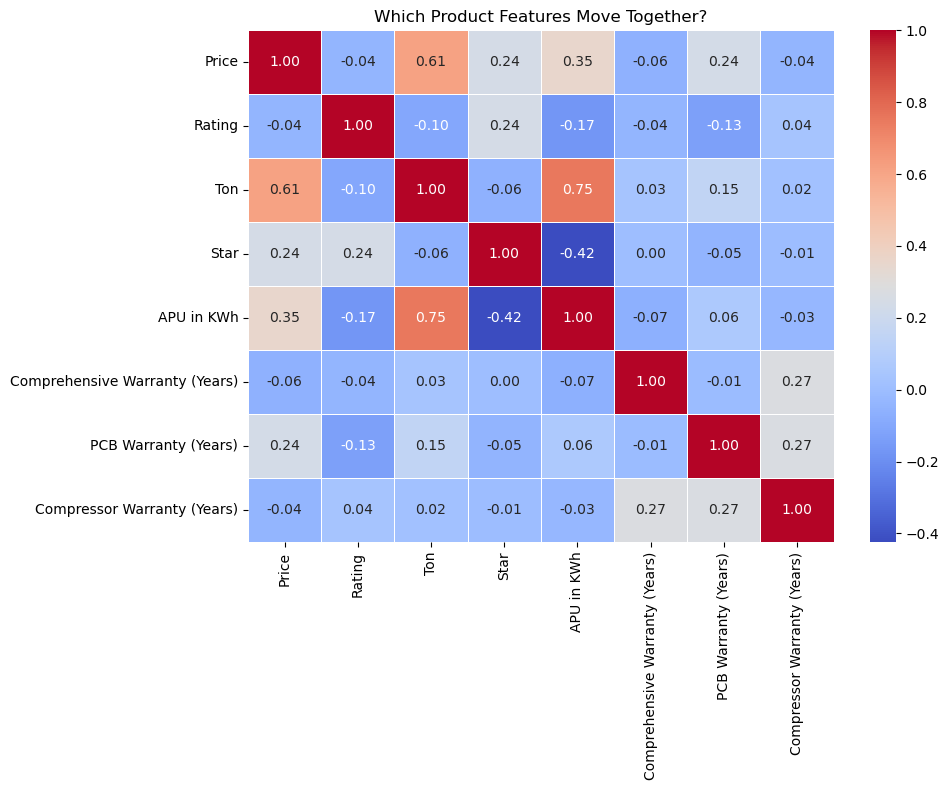

In [530]:
numeric_columns = ['Price', 'Rating', 'Ton', 'Star', 'APU in KWh', 'Comprehensive Warranty (Years)', 'PCB Warranty (Years)', 'Compressor Warranty (Years)']

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)


plt.title('Which Product Features Move Together?')
plt.tight_layout()
plt.show()

### My Interpretations on Feature Relationships :
- The correlation analysis reveals that tonnage has the strongest positive relationship with annual power consumption (0.75), indicating that larger-capacity air conditioners generally consume more electricity. Price also shows a moderate positive correlation with tonnage (0.61) and a weaker positive relationship with annual power consumption (0.35), suggesting that higher-capacity models tend to be more expensive. In contrast, customer ratings and energy-efficiency star ratings exhibit relatively weak correlations with price, indicating that these factors alone do not strongly determine product pricing.

### Do Higher Star Ratings Lead to Higher Air Conditioner Prices?

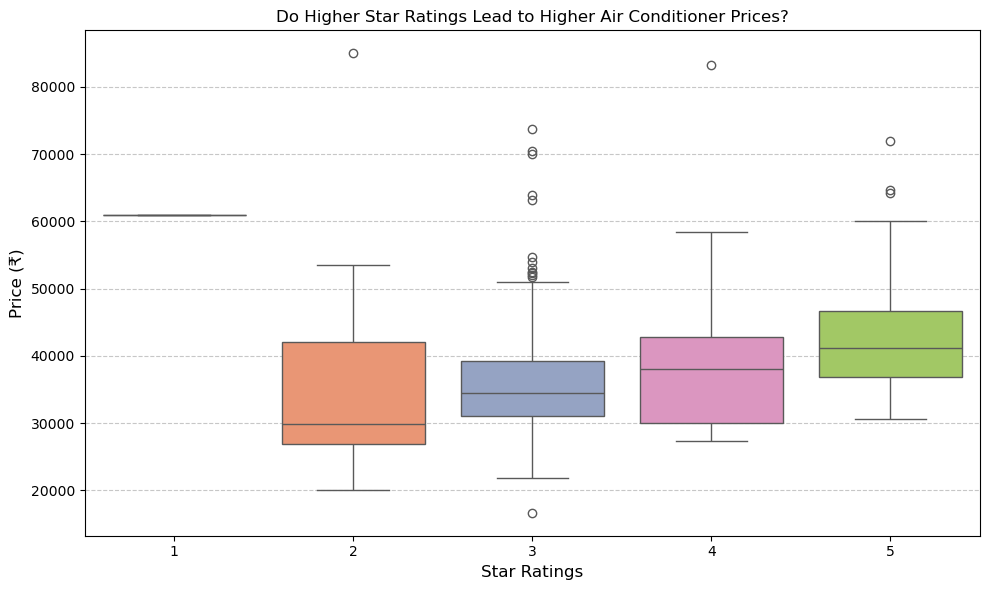

In [504]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Star',y='Price',hue='Star',data=df,palette='Set2',legend=False)

plt.title('Do Higher Star Ratings Lead to Higher Air Conditioner Prices?')
plt.xlabel('Star Ratings',fontsize=12)
plt.ylabel('Price (₹)',fontsize=12)
plt.grid(axis='y',linestyle='--',alpha=0.7)

plt.tight_layout()
plt.show()

### My interpretations on Price by Star Ratings:

* The box plot indicates that higher energy-efficiency star ratings are generally associated with higher air conditioner prices, although the relationship is not perfectly linear. 2-star models are concentrated in the lower price range, while 4-star and 5-star models exhibit higher median prices, suggesting that improved energy efficiency often comes at a premium. However, the considerable overlap in price ranges and the presence of outliers across multiple star-rating categories indicate that star rating is not the sole factor influencing price. Other product characteristics, such as cooling capacity (tonnage), brand positioning, smart features, and warranty offerings, also contribute to pricing differences.

### How Do Tonnage and Star Ratings Influence Air Conditioner Prices?

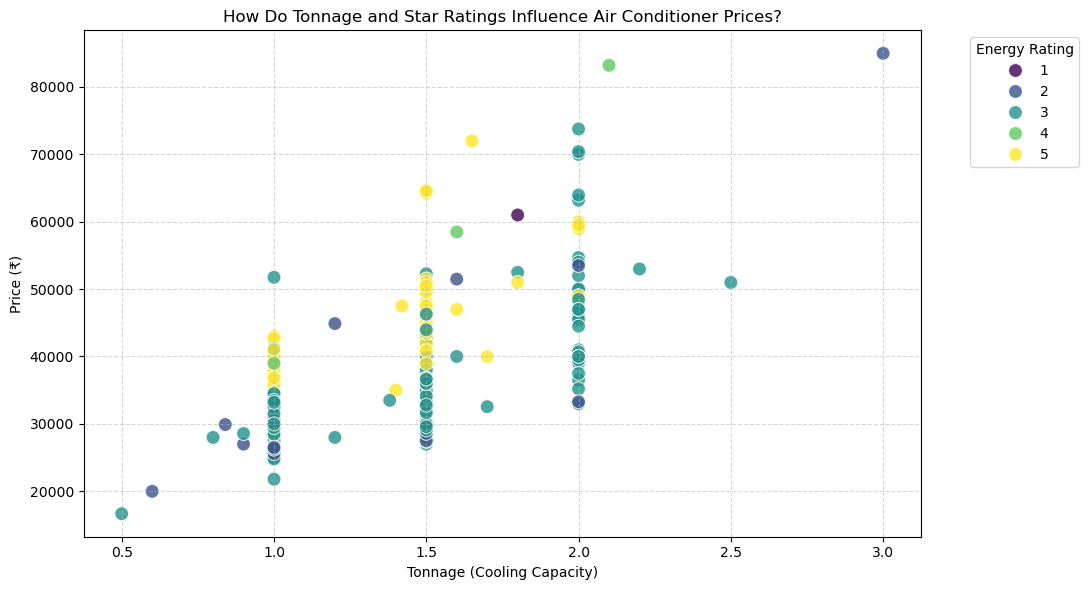

In [494]:
plt.figure(figsize=(11,6))

sns.scatterplot(x='Ton', y='Price', hue='Star', data=df, palette='viridis', s=100,alpha=0.8)

plt.title('How Do Tonnage and Star Ratings Influence Air Conditioner Prices?')
plt.xlabel('Tonnage (Cooling Capacity)')
plt.ylabel('Price (₹)')
plt.legend(title='Energy Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### My interpretions on Ac's prices by tonnage

* The multivariate analysis shows that both cooling capacity (tonnage) and energy-efficiency star ratings influence air conditioner pricing. Within the 1.0-ton category, 3-star models generally appear in lower price ranges, whereas 5-star models are more frequently found at higher price points, indicating a premium for improved energy efficiency. A similar pricing pattern is observed among 1.5-ton and 2.0-ton air conditioners, where higher star-rated models generally occupy higher price ranges. The visualization also shows that 3-star and 4-star air conditioners are more widely represented across different tonnage categories, while 5-star models are comparatively fewer and typically positioned in the higher price segment.

## Final Project Conclusion

This analysis demonstrates that air conditioner prices are primarily influenced by cooling capacity, energy-efficiency star ratings, and brand positioning. Premium brands such as Mitsubishi occupy the highest price segment, while most manufacturers focus on budget and mid-range offerings. The analysis also highlights that 3-star and 4-star models dominate the available product listings, whereas 5-star models are fewer but generally command higher prices within the same tonnage category. Overall, this project illustrates how web scraping and exploratory data analysis can uncover meaningful business insights from real-world e-commerce data.

## Project Limitations:
- The dataset was collected exclusively from Flipkart, so the analysis may not represent the complete Indian air conditioner market or pricing across other e-commerce platforms and offline retailers.
- Product prices and availability are dynamic and may change over time due to discounts, seasonal sales, promotional offers, or inventory updates. Therefore, the findings reflect the market conditions at the time the data was scraped.
- The analysis is based on listed product information only and does not include actual sales volume, customer purchase behavior, or revenue data. As a result, conclusions relate to product availability and pricing rather than market demand.
- Some product specifications extracted through web scraping may contain inconsistencies or missing values due to differences in product descriptions across listings.
- While this project identifies relationships between variables such as price, tonnage, and star ratings, it does not establish causal relationships. Other factors, such as installation services, brand reputation, promotional offers, smart features, and regional pricing strategies, may also influence product prices.